# All bands viz

This notebook is used to get a sense of the downloaded and aggregated bands for each scene.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.io import RAW_DIR

In [3]:
file_name = RAW_DIR / "DJF/S2B_MSIL2A_20220220T110959_N0510_R137_T30STG_20240516T171047_ALLBANDS.tif"

In [4]:
file_name

PosixPath('/Users/stepit/Repositories/projects/lu-lc-classification-with-unet/data/raw/DJF/S2B_MSIL2A_20220220T110959_N0510_R137_T30STG_20240516T171047_ALLBANDS.tif')

In [19]:
!gdalinfo -stats {file_name}

Driver: GTiff/GeoTIFF
Files: /Users/stepit/Repositories/projects/lu-lc-classification-with-unet/data/raw/DJF/S2B_MSIL2A_20220220T110959_N0510_R137_T30STG_20240516T171047_ALLBANDS.tif
Size is 5169, 5181
Coordinate System is:
PROJCRS["WGS 84 / UTM zone 30N",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4326]],
    CONVERSION["UTM zone 30N",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-3,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
           

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [6]:
with rasterio.open(file_name, "r") as src:
    data = src.read()
    profile = src.profile
    bounds = src.bounds

In [7]:
data.shape

(11, 5181, 5169)

In [8]:
profile

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 5169, 'height': 5181, 'count': 11, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32630"]]'), 'transform': Affine(10.0, 0.0, 200780.0,
       0.0, -10.0, 4151040.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}

In [9]:
profile["crs"], profile["transform"]

(CRS.from_wkt('PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32630"]]'),
 Affine(10.0, 0.0, 200780.0,
        0.0, -10.0, 4151040.0))

In [10]:
def robust_plot(data, bounds: list | None = None) -> None:
    """
    Plot the provided data with the Viridis cmap and cmap max and min given
    by the 2nd and 98th percentiles of the data.
    """
    vmin, vmax = np.percentile(data, [2, 98])
    extent = []
    if bounds is not None:
        left, bottom, right, top = bounds
        extent = [left, right, bottom, top]
    plt.imshow(
        data, 
        vmin=vmin, 
        vmax=vmax, 
        extent=extent, 
        cmap="viridis",
    )

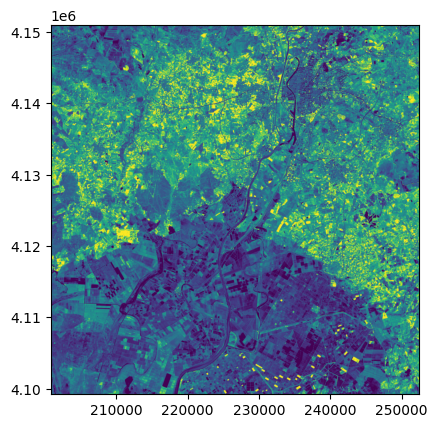

In [11]:
robust_plot(data[9], bounds)

In [12]:
from src.config import load_sentinel2_config

cfg = load_sentinel2_config()

In [13]:
band_names = [band.split("_")[0] for band in cfg.msi.get_bands()]
band_names

['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B11', 'B12', 'B8A', 'SCL']

In [14]:
import math

In [15]:
def plot_bands(data, bands, bounds=None):
    n, h, w = data.shape
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)
 
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten()
 
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top] if bounds else None
 
    for i, ax in enumerate(axes):
        if i >= n:
            ax.set_visible(False)
            continue
        band = data[i].astype(float)
        lo, hi = np.percentile(band[band > 0], [2, 98])
        ax.imshow(np.clip((band - lo) / (hi - lo), 0, 1), extent=extent, origin="upper", cmap="gray")
        ax.set_title(f"Band {bands[i]}", fontsize=9)
 
    plt.tight_layout()

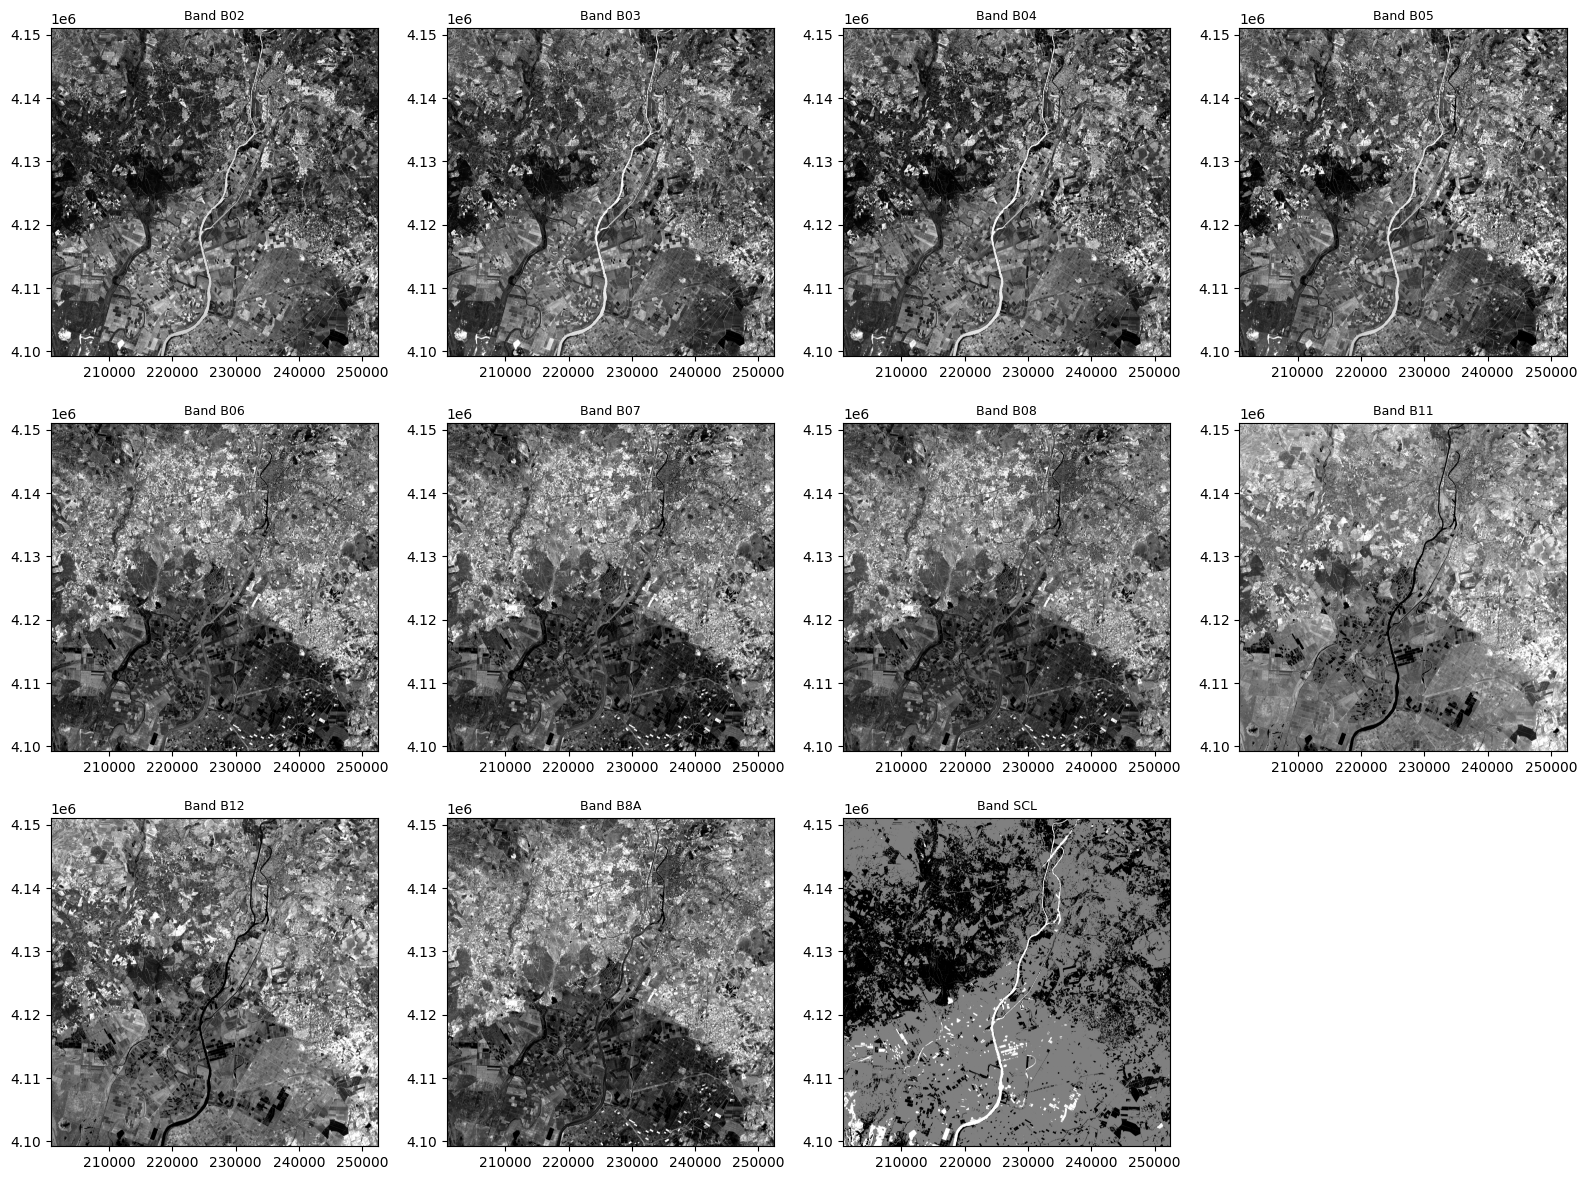

In [16]:
plot_bands(data, band_names, bounds)